In [12]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = False # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: False, Database: bird


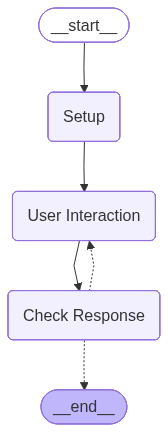

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]
    try: 
        # Se o experimento já foi avaliado, pula para o próximo
        if exp_id in processed_ids or exp_id == "14":
            print(f"Pulando experimento {exp_id} já processado.")
            continue

        print(f"Processando experimento {exp_id}...")

        config =  {"recursion_limit": 50}
        # Invoca a avaliação com as configurações estendidas
        eval_result = eval_graph.invoke({
            "experiment": experiment,
            "max_retries": 2,
            "debug_mode": True,
            "model_version": model_version,
            "experiment_type": experiment_type,
           
        }, config=config)

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get("experiment_config", {
                "max_retries": 2,
                "model_version": model_version,
                "timestamp": datetime.now().isoformat(),
                "experiment_type": experiment_type
            }),
            "experiment_eval": eval_result["experiment_eval"]
        })

        # Atualiza o arquivo salvando o resultado atual
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)
    except Exception as e:
        print(f"Erro ao processar experimento {exp_id}: {e}")


Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Pulando experimento 14 já processado.
Processando experimento 15...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Can you show me the total points scored by each constructor?


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "What are the total points scored by each constructor?",
    "schema_linking": ["formula_1_constructors", "formula_1_constructorresults"],
    "answer": "The total points scored by each constructor are as follows:\n\n1. Ferrari: 7081.5 points\n2. McLaren: 5232.5 points\n3. Red Bull: 3750.5 points\n4. Williams: 3541.0 points\n5. Mercedes: 3525.0 points\n\nThere are a total of 172 constructors in the list. Let me know if you'd like details for any specific constructor.",
    "sql": "SELECT c.name AS constructor_name, SUM(cr.points) AS total_points\nFROM formula_1_constructors c\nJOIN formula_1_constructorresults cr ON c.constructorid = cr.constructorid\nGROUP BY c.name\nORDER BY total_points DESC;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What are the total points scored by each constructor?",
    "schema_linking": ["formula_1_constructors", "form

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['CONSTRUCTORID', 'TOTAL_POINTS'], dtype='object')
Adj. True cols: Index(['TOTAL_POINTS'], dtype='object')
Predicted cols: Index(['CONSTRUCTOR_NAME', 'TOTAL_POINTS'], dtype='object')
Adj. Predicted cols: Index(['TOTAL_POINTS'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Display the total points scored by each constructor.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Can you show me the total points scored by each constructor?', 'agent_reply': "The total points scored by each constructor are as follows:\n\n1. Ferrari: 7081.5 points\n2. McLaren: 5232.5 points\n3. Red Bull: 3750.5 points\n4. Williams: 3541.0 points\n5. Mercedes: 3525.0 points\n\nThere are a total of 172 constructors in the list. Let me know if you'd like details for any specific constructor.", 'evaluation': {'text_to_sql_input': 'What are the total points scored by each constructor?', 'user_intention': 'Displa

...

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['NAME'], dtype='object')
Adj. True cols: Index([], dtype='object')
Predicted cols: Index(['NAME'], dtype='object')
Adj. Predicted cols: Index([], dtype='object')
[AI as JUDGE sql query correctness] Result: F with 0.9997951693480744 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 426, 'total_tokens': 428, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Retrieve constructors along with their race standings and their race results.",
    "schema_linking": ["formula_1_constructors", "formula_1_constructorstandings", "formula_1_results"],
    "answer": "I couldn't retrieve the requested data because the database connection failed.",
    "sql": "SELECT c.name AS constructor_name, cs.points AS standings_points, cs.position AS standings_position, r.points AS results_points, r.position AS results_position FROM formula_1_constructors c JOIN formula_1_constructorstandings cs ON c.constructorid = cs.constructorid JOIN formula_1_results r ON c.constructorid = r.constructorid"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Retrieve constructors along with their race standings and their race results.",
    "schema_linking": ["formula_1_constructors", "formula_1_constructorstandings", "formula_1_results"],
    "an

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


In [6]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]
    try: 
        # Se o experimento já foi avaliado, pula para o próximo
        if exp_id in processed_ids or exp_id in ["14","28"]:
            print(f"Pulando experimento {exp_id} já processado.")
            continue

        print(f"Processando experimento {exp_id}...")

        config =  {"recursion_limit": 50}
        # Invoca a avaliação com as configurações estendidas
        eval_result = eval_graph.invoke({
            "experiment": experiment,
            "max_retries": 2,
            "debug_mode": True,
            "model_version": model_version,
            "experiment_type": experiment_type,
           
        }, config=config)

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get("experiment_config", {
                "max_retries": 2,
                "model_version": model_version,
                "timestamp": datetime.now().isoformat(),
                "experiment_type": experiment_type
            }),
            "experiment_eval": eval_result["experiment_eval"]
        })

        # Atualiza o arquivo salvando o resultado atual
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)
    except Exception as e:
        print(f"Erro ao processar experimento {exp_id}: {e}")


Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Pulando experimento 14 já processado.
Pulando experimento 15 já processado.
Pulando experimento 16 já processado.
Pulando experimento 17 já processado.
Pulando experimento 18 já processado.
Pulando experimento 19 já processado.
Pulando experimento 20 já processado.
Pulando experimento 21 já processado.
Pulando experimento 22 já processado.
Pulando experimento 23 já processado.
Pulando experimento 25 já processado.
Pulando experimento 26 já processado.
Pulando experimento 28 já processado.
Processando experimento 29...
[NODE] Setup Node entered.
-

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Who scored the highest points in a single race?",
    "schema_linking": ["formula_1_results"],
    "answer": "Driver with ID 1 scored the highest points, which is 50 points in race ID 918.",
    "sql": "SELECT r.driverid, r.points, r.raceid FROM formula_1_results r WHERE r.points = (SELECT MAX(points) FROM formula_1_results)"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Who scored the highest points in a single race?",
    "schema_linking": ["formula_1_results"],
    "answer": "Driver with ID 1 scored the highest points, which is 50 points in race ID 918.",
    "sql": "SELECT r.driverid, r.points, r.raceid FROM formula_1_results r WHERE r.points = (SELECT MAX(points) FROM formula_1_results)"
}.

[INFO] Avaliando o resultado: {'input': 'Who scored the highest points in a single race?', 'schema_linking': ['formula_1_results'], 'answer': 'Driver with 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\

[INFO] O resultado da execução foi: {
    "input": "What is the total number of wins for the driver with ID 1?",
    "schema_linking": ["formula_1_driverstandings"],
    "answer": "The total number of wins for the driver with ID 1 is 542.",
    "sql": "SELECT SUM(wins) AS total_wins FROM formula_1_driverstandings WHERE driverid = 1;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What is the total number of wins for the driver with ID 1?",
    "schema_linking": ["formula_1_driverstandings"],
    "answer": "The total number of wins for the driver with ID 1 is 542.",
    "sql": "SELECT SUM(wins) AS total_wins FROM formula_1_driverstandings WHERE driverid = 1;"
}.

[INFO] Avaliando o resultado: {'input': 'What is the total number of wins for the driver with ID 1?', 'schema_linking': ['formula_1_driverstandings'], 'answer': 'The total number of wins for the driver with ID 1 is 542.', 'sql': 'SELECT SUM(wi

...

[INFO] O resultado da execução foi: {
    "input": "How many drivers are there grouped by their nationality?",
    "schema_linking": ["formula_1_drivers"],
    "answer": "The number of drivers grouped by their nationality are as follows: British (162), German (49), Australian (17), Indian (2), New Zealander (8), Liechtensteiner (1), Rhodesian (4), American-Italian (1), Polish (1), Danish (5), Monegasque (3), South African (23), Chilean (1), Thai (1), American (157), Canadian (13), Argentine (24), Czech (1), Spanish (15), Japanese (19), Malaysian (1), Venezuelan (3), Argentine-Italian (1), East German (3), French (72), Brazilian (31), Colombian (3), Portuguese (4), Dutch (17), Irish (5), Belgian (23), Swedish (10), Finnish (9), Italian (99), Hungarian (1), Swiss (23), Russian (2), Austrian (15), Mexican (6), Uruguayan (4), Indonesian (1).",
    "sql": "SELECT nationality, COUNT(driverid) AS driver_count FROM formula_1_drivers GROUP BY nationality"
}.

-----------------------------------

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\

[INFO] O resultado da execução foi: {
    "input": "Show lap times for each driver.",
    "schema_linking": ["formula_1_drivers", "formula_1_laptimes"],
    "answer": "Here are some lap times for drivers:\n1. Lewis Hamilton - Lap 1: 1:49.088, Lap 2: 1:33.740, Lap 3: 1:31.600, Lap 4: 1:31.067, Lap 5: 1:32.129...\n2. Kevin Magnussen - Lap 31: 2:17.486, Lap 32: 1:57.179, Lap 33: 1:45.708, Lap 34: 1:44.854, Lap 35: 1:44.680...\nNote: The database contains over 420,369 rows of lap time records.",
    "sql": "SELECT d.forename, d.surname, lt.lap, lt.time FROM formula_1_drivers d JOIN formula_1_laptimes lt ON d.driverid = lt.driverid"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Show lap times for each driver.",
    "schema_linking": ["formula_1_drivers", "formula_1_laptimes"],
    "answer": "Here are some lap times for drivers:\n1. Lewis Hamilton - Lap 1: 1:49.088, Lap 2: 1:33.740, Lap 3: 1:31.600, Lap 4:

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


KeyboardInterrupt: 

In [14]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]
    try: 
        # Se o experimento já foi avaliado, pula para o próximo
        if exp_id in processed_ids or exp_id in ["14","28", "33", "34"]:
            print(f"Pulando experimento {exp_id} já processado.")
            continue

        print(f"Processando experimento {exp_id}...")

        config =  {"recursion_limit": 50}
        # Invoca a avaliação com as configurações estendidas
        eval_result = eval_graph.invoke({
            "experiment": experiment,
            "max_retries": 2,
            "debug_mode": True,
            "model_version": model_version,
            "experiment_type": experiment_type,
           
        }, config=config)

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get("experiment_config", {
                "max_retries": 2,
                "model_version": model_version,
                "timestamp": datetime.now().isoformat(),
                "experiment_type": experiment_type
            }),
            "experiment_eval": eval_result["experiment_eval"]
        })

        # Atualiza o arquivo salvando o resultado atual
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)
    except Exception as e:
        print(f"Erro ao processar experimento {exp_id}: {e}")


Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Pulando experimento 14 já processado.
Pulando experimento 15 já processado.
Pulando experimento 16 já processado.
Pulando experimento 17 já processado.
Pulando experimento 18 já processado.
Pulando experimento 19 já processado.
Pulando experimento 20 já processado.
Pulando experimento 21 já processado.
Pulando experimento 22 já processado.
Pulando experimento 23 já processado.
Pulando experimento 25 já processado.
Pulando experimento 26 já processado.
Pulando experimento 28 já processado.
Pulando experimento 29 já processado.
Pulando experimento 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: 
{
    "input": "How many circuits are there in each country and location?",
    "schema_linking": ["FORMULA_1_CIRCUITS"],
    "answer": "There are 70 unique country-location combinations for circuits. Each country and location combination generally has 1 circuit, such as Spain in Montmeló, Canada in Montreal, France in Magny Cours, and so on.",
    "sql": "SELECT country, location, COUNT(circuitid) AS circuit_count FROM formula_1_circuits GROUP BY country, location"
}
.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: 
{
    "input": "How many circuits are there in each country and location?",
    "schema_linking": ["FORMULA_1_CIRCUITS"],
    "answer": "There are 70 unique country-location combinations for circuits. Each country and location combination generally has 1 circuit, such as Spain in Montmeló, Canada in Montreal, France in Magny Cours, and so on.",
    "sql": "SELECT country

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['COUNTRY', 'LOCATION', 'CIRCUIT_COUNT'], dtype='object')
Adj. True cols: Index(['COUNTRY', 'LOCATION', 'CIRCUIT_COUNT'], dtype='object')
Predicted cols: Index(['COUNTRY', 'LOCATION', 'CIRCUIT_COUNT'], dtype='object')
Adj. Predicted cols: Index(['COUNTRY', 'LOCATION', 'CIRCUIT_COUNT'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Count the number of circuits in each country and location.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'How many circuits are there in each country and location?', 'agent_reply': 'There are 70 unique country-location combinations for circuits. Each country and location combination generally has 1 circuit, such as Spain in Montmeló, Canada in Montreal, France in Magny Cours, and so on.', 'evaluation': {'text_to_sql_input': 'How many circuits are there in each country and location?', 'user_intention': 'Count the number of circuits in each country and l

...

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Find the lowest position achieved by any constructor.",
    "schema_linking": ["formula_1_constructorstandings"],
    "answer": "The lowest position achieved by any constructor is 1.",
    "sql": "SELECT MIN(position) AS lowest_position FROM formula_1_constructorstandings;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Find the lowest position achieved by any constructor.",
    "schema_linking": ["formula_1_constructorstandings"],
    "answer": "The lowest position achieved by any constructor is 1.",
    "sql": "SELECT MIN(position) AS lowest_position FROM formula_1_constructorstandings;"
}.

[INFO] Avaliando o resultado: {'input': 'Find the lowest position achieved by any constructor.', 'schema_linking': ['formula_1_constructorstandings'], 'answer': 'The lowest position achieved by any constructor is 1.', 'sql': 'SELECT MIN(position) AS lowest_posi

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\

[INFO] O resultado da execução foi: {
    "input": "How many constructors have scored more than 10 points?",
    "schema_linking": ["formula_1_constructorstandings"],
    "answer": "There are 4597 constructors who have scored more than 10 points.",
    "sql": "SELECT COUNT( constructorid) AS num_constructors FROM formula_1_constructorstandings WHERE points > 10;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "How many constructors have scored more than 10 points?",
    "schema_linking": ["formula_1_constructorstandings"],
    "answer": "There are 4597 constructors who have scored more than 10 points.",
    "sql": "SELECT COUNT( constructorid) AS num_constructors FROM formula_1_constructorstandings WHERE points > 10;"
}.

[INFO] Avaliando o resultado: {'input': 'How many constructors have scored more than 10 points?', 'schema_linking': ['formula_1_constructorstandings'], 'answer': 'There are 4597 const

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
